1. Import Library

In [ ]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

2. Load Data

In [ ]:
df = pd.read_csv("Titanic-Dataset.csv") 
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


3. Exploratoty Data Analysis (EDA)

In [5]:
# Informasi dataset
df.info

<bound method DataFrame.info of      PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                   

In [4]:
# Statistik deskriptif
df.describe()
df.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,B96 B98,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [6]:
# Cek Missing Value
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

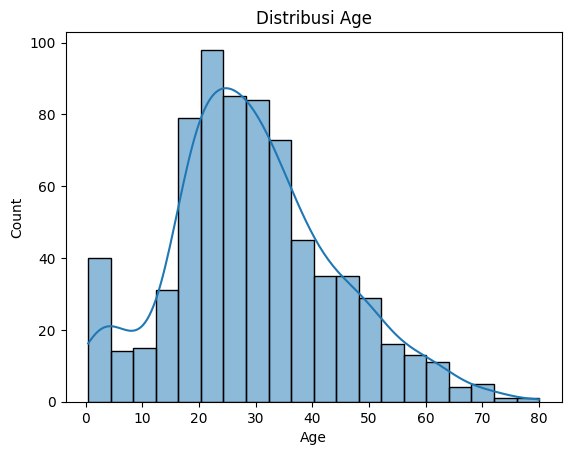

In [7]:
# Distribusi Age
sns.histplot(df['Age'], kde=True)
plt.title("Distribusi Age")
plt.show()

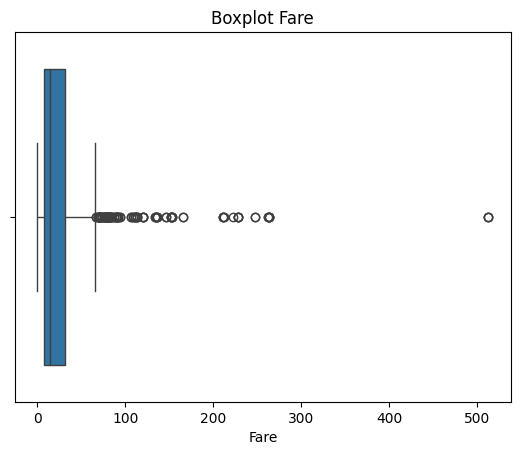

In [8]:
# Boxplot Fare (Deteksi Outlier)
sns.boxplot(x=df['Fare'])
plt.title("Boxplot Fare")
plt.show()

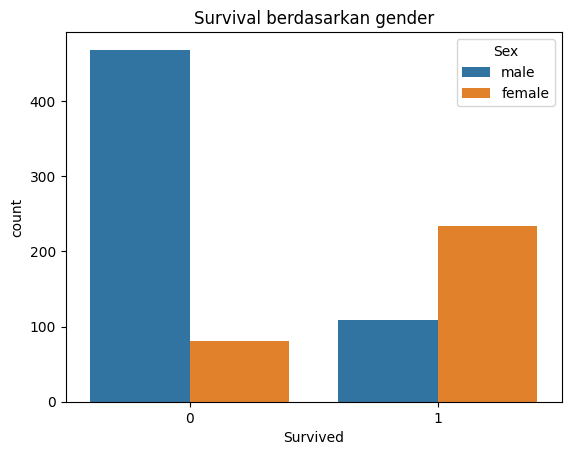

In [9]:
# Survival berdasarkan gender
sns.countplot(x='Survived', hue='Sex', data=df)
plt.title("Survival berdasarkan gender")
plt.show()

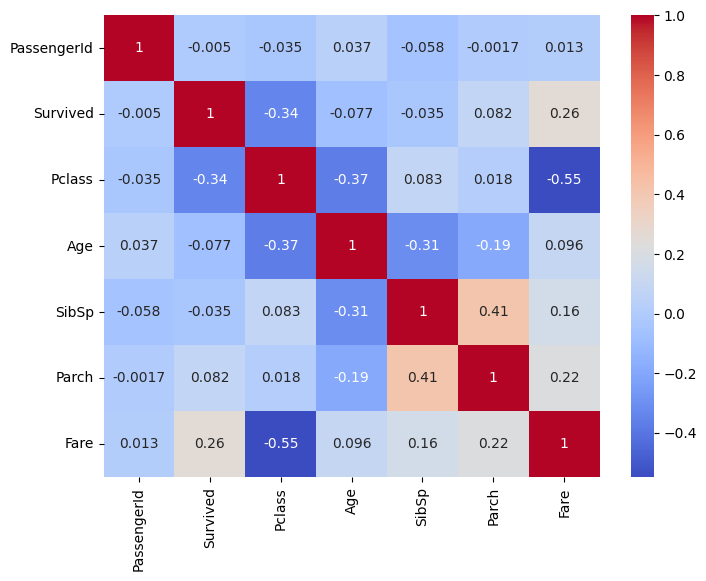

In [14]:
# Korelasi
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

4. Data Preprocessing

In [15]:
# Tangani missing value

# Median
df['Age'].fillna(df['Age'].median(), inplace=True)

# Modus
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Drop/hapus karena terlalu banyak yang missing value
df.drop(columns=['Cabin'], inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_18092\2875385478.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


In [16]:
# Encoding variabel kategorikal
df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)

In [17]:
# Hapus kolom tidak relevan
df.drop(columns=['Name','Ticket','PassengerId'], inplace=True)

In [19]:
# Tangani outlier (Metode IQR - Fare)
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['Fare'] >= lower) & (df['Fare'] <= upper)]

In [20]:
# Normalisasi data numerik
scaler = StandardScaler()
numerical_cols = ['Age', 'Fare', 'SibSp', 'Parch']

df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

5. Data Setelah Preprocessing

In [24]:
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,-0.528321,0.625606,-0.433718,-0.779117,True,False,True
2,1,3,-0.215182,-0.486423,-0.433718,-0.729373,False,False,True
3,1,1,0.489381,0.625606,-0.433718,2.599828,False,False,True
4,0,3,0.489381,-0.486423,-0.433718,-0.720161,True,False,True
5,0,3,-0.058613,-0.486423,-0.433718,-0.690071,True,True,False


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 775 entries, 0 to 890
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    775 non-null    int64  
 1   Pclass      775 non-null    int64  
 2   Age         775 non-null    float64
 3   SibSp       775 non-null    float64
 4   Parch       775 non-null    float64
 5   Fare        775 non-null    float64
 6   Sex_male    775 non-null    bool   
 7   Embarked_Q  775 non-null    bool   
 8   Embarked_S  775 non-null    bool   
dtypes: bool(3), float64(4), int64(2)
memory usage: 44.7 KB


In [26]:
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,775.000000,775.00000,7.750000e+02,7.750000e+02,7.750000e+02,7.750000e+02
mean,0.339355,2.48000,-1.008512e-16,-9.168293e-18,1.719055e-17,7.334635e-17
std,0.473796,0.73439,1.000646e+00,1.000646e+00,1.000646e+00,1.000646e+00
min,0.000000,1.00000,-2.217707e+00,-4.864227e-01,-4.337180e-01,-1.313411e+00
25%,0.000000,2.00000,-5.283213e-01,-4.864227e-01,-4.337180e-01,-7.315244e-01
50%,0.000000,3.00000,-5.861258e-02,-4.864227e-01,-4.337180e-01,-3.553671e-01
75%,1.000000,3.00000,4.110961e-01,6.256056e-01,-4.337180e-01,6.026763e-01
max,1.000000,3.00000,4.012196e+00,5.073719e+00,7.205634e+00,3.476807e+00
